In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty"
]

train_df = pd.read_csv("../data/KDDTrain+.txt", names=col_names)
test_df  = pd.read_csv("../data/KDDTest+.txt",  names=col_names)

train_df["label"] = train_df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)
test_df["label"] = test_df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

le = LabelEncoder()
categorical_cols = ["protocol_type", "service", "flag"]
for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.fit_transform(test_df[col])

train_df["label_encoded"] = le.fit_transform(train_df["label"])
test_df["label_encoded"]  = le.transform(test_df["label"])

features_to_drop = ["label", "difficulty", "label_encoded"]
X_train = train_df.drop(columns=features_to_drop)
y_train = train_df["label_encoded"]
X_test  = test_df.drop(columns=features_to_drop)
y_test  = test_df["label_encoded"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Retrain XGBoost and Random Forest only (fastest two, needed for plots)
print("Retraining XGBoost...", end=" ", flush=True)
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     n_jobs=-1, eval_metric="logloss", verbosity=0)
xgb.fit(X_train_scaled, y_train)
print("done.")

print("Retraining Random Forest...", end=" ", flush=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
print("done.")

print("\nReady for evaluation.")

Retraining XGBoost... done.
Retraining Random Forest... done.

Ready for evaluation.


In [2]:
results_df = pd.read_csv("../outputs/model_results.csv")
print(results_df.to_string(index=False))

        Model  Accuracy  Precision  Recall  F1 Score
      XGBoost     80.40      69.54   96.99     81.00
Decision Tree     79.04      67.97   97.12     79.97
          SVM     78.14      66.76   98.07     79.45
Random Forest     77.34      66.14   97.14     78.69
          KNN     76.57      65.24   97.62     78.21


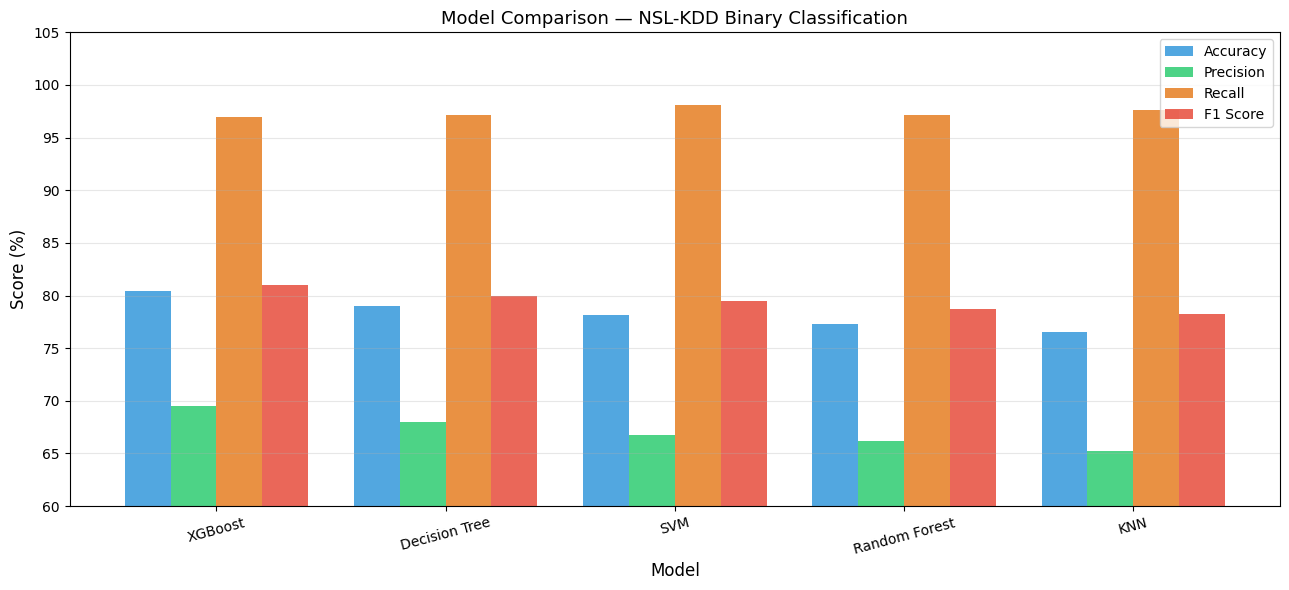

Chart saved.


In [3]:
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df["Model"]))
width = 0.2
colors = ["#3498db", "#2ecc71", "#e67e22", "#e74c3c"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric],
                  width, label=metric, color=color, alpha=0.85)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_title("Model Comparison — NSL-KDD Binary Classification", fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=15)
ax.set_ylim(60, 105)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

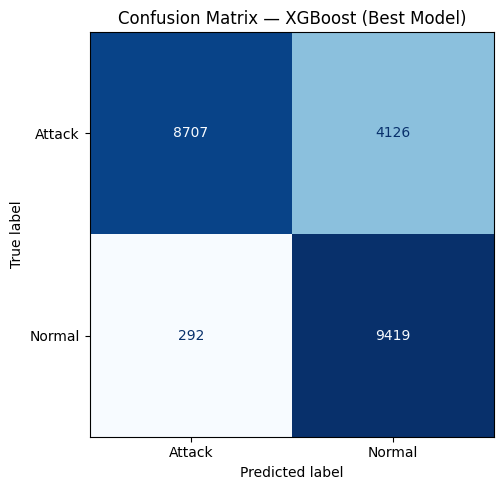

True Negatives  — attacks correctly identified:   8,707
False Positives — normal traffic flagged:         4,126
False Negatives — attacks missed:                 292
True Positives  — normal traffic correctly passed:9,419

False Positive Rate: 32.2%
Attack Detection Rate (Recall): 97.0%


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_xgb = xgb.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Attack", "Normal"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost (Best Model)", fontsize=12)

plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  — attacks correctly identified:   {tn:,}")
print(f"False Positives — normal traffic flagged:         {fp:,}")
print(f"False Negatives — attacks missed:                 {fn:,}")
print(f"True Positives  — normal traffic correctly passed:{tp:,}")
print(f"\nFalse Positive Rate: {fp/(fp+tn)*100:.1f}%")
print(f"Attack Detection Rate (Recall): {tp/(tp+fn)*100:.1f}%")

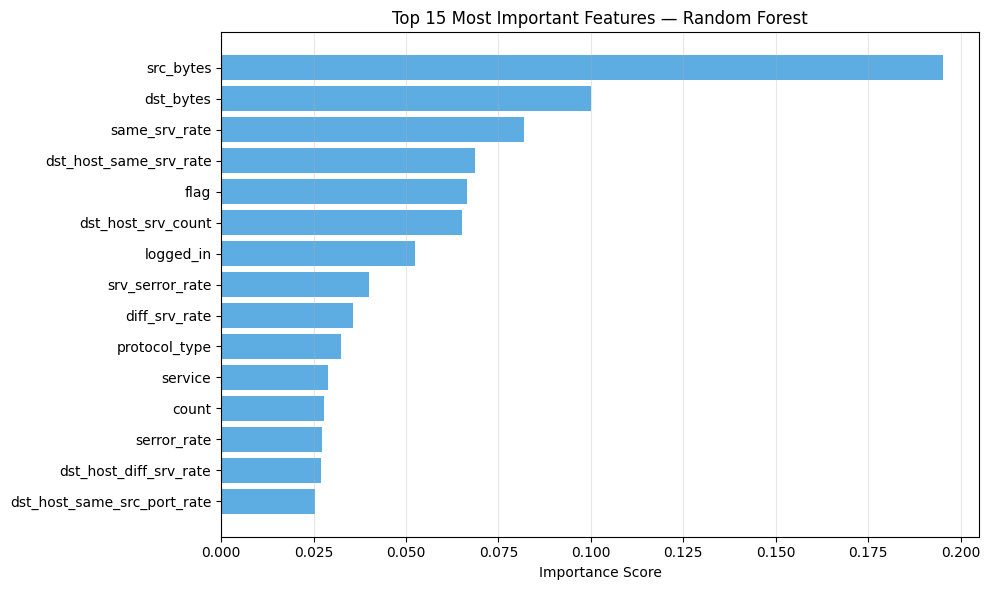


Top 5 most important features:
               Feature  Importance
             src_bytes    0.195155
             dst_bytes    0.099976
         same_srv_rate    0.081802
dst_host_same_srv_rate    0.068639
                  flag    0.066547


In [5]:
feature_importance = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance["Feature"][::-1],
        feature_importance["Importance"][::-1],
        color="#3498db", alpha=0.8)
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Most Important Features — Random Forest")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.head(5).to_string(index=False))